In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (18, 6),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

C:\Users\chris\AppData\Local\Temp\ipykernel_11708\1746947010.py:27: LicenceNotice:


Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence



In [ ]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP
from TB.IRSwaptionsTB import IRSwaptionsTB
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

# curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
curve_mdp = IRSwapsMDP(source="citivelo_excel_rl")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
vol_mdp = IRSwaptionMDP(
    source="CITIVELO-RL",
    curve_source="citivelo_excel_rl",
    request_defaults={"verify": False},
)

ts_builder = TimeseriesBuilder()

In [7]:
# tb = IRSwapsTB(IRSwapsMDP(source="eris_live_intraday"), show_tqdm=True, use_ts_cache=False)
# q  = UnifiedQuery(curve="USD-SOFR-1D", tenor="2y/10y", value=UnifiedValue.IRS_RATE)   # bare curve name
# df = TimeseriesBuilder().get_timeseries(
# 		start=NYC_tz.localize(datetime.datetime(2026,7,24,2,0)),
# 		end  =NYC_tz.localize(datetime.datetime(2026,7,24,17,00)),
# 		queries=[q], freq="1min", n_jobs=8, routers={"IRS": tb}, ignore_cache_miss=True)
# df

In [8]:
# plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
# plot(df["USD-SOFR-1D 2y/5y CURVE RATE"], which="left")
# legend(show_date=True)
# plt.show()

In [26]:
start = NYC_tz.localize(datetime.datetime(2025, 8, 1, 17, 00))
end = NYC_tz.localize(datetime.datetime(2026, 8, 14, 17, 00))
# start = datetime.date(2021, 1, 1)
# end = datetime.date(2026, 5, 11)

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
		# UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="10y2y/12y3y/15y5y",
        #     value=UnifiedValue.IRS_RATE,
        # ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="1y5y/1y10y/1y30y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			selector={"shorthand":  "3Yx10Y", "strike": "ATMF"},
			structure=UnifiedStructure.IRSWAPTION_STRADDLE,
			value=UnifiedValue.IRSWAPTION_NVOL,
		)
        # UnifiedQuery(
		# 	cusip="CT2/CT10",
		# 	value=UnifiedValue.FRB_YTM,
        # )
    ],
    n_jobs=12,
    routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
        "IRSWAPTION":  IRSwaptionsTB(vol_mdp, show_tqdm=True),
    },
	# ignore_cache=True
)
df

PRICING IRSWAPTIONS.: 0it [00:00, ?it/s]


,USD-SOFR-1D 1y5y/1y10y/1y30y FLY RATE,USD-SOFR-1D 3Yx10Y STRADDLE BUY ATMF NVOL
Date,,
2025-08-01,14.374192,91.1998
2025-08-04,14.136963,90.7386
2025-08-05,14.019374,90.3103
2025-08-06,14.137387,90.0880
2025-08-07,13.184505,89.7322
...,...,...
2026-08-10,2.802805,84.1107
2026-08-11,2.910188,83.7026
2026-08-12,2.469045,83.0664


In [27]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
# plot(df["USD-SOFR-1D 10y2y/12y3y/15y5y FLY RATE"])
# plot(df["CT5/CT7 CURVE YTM"], which="left")
# plot(df["USD-SOFR-1D 5y/10y/30y FLY RATE"], which="left")
plot(df["USD-SOFR-1D 1y5y/1y10y/1y30y FLY RATE"], which="left")
plot(df["USD-SOFR-1D 3Yx10Y STRADDLE BUY ATMF NVOL"], which="right")
# plot(df["CT10/CT30 CURVE YTM"], which="right")
# plot(df["USD-SOFR-1D 10Y OUTRIGHT RATE"], which="right")
legend(show_date=True)
plt.show()

                                      OLS Regression Results                                     
Dep. Variable:     USD-SOFR-1D 1y5y/1y10y/1y30y FLY RATE   R-squared:                       0.322
Model:                                               OLS   Adj. R-squared:                  0.320
Method:                                    Least Squares   F-statistic:                     122.7
Date:                                   Sun, 16 Aug 2026   Prob (F-statistic):           1.40e-23
Time:                                           10:00:31   Log-Likelihood:                -593.73
No. Observations:                                    260   AIC:                             1191.
Df Residuals:                                        258   BIC:                             1199.
Df Model:                                              1                                         
Covariance Type:                               nonrobust                                         
                    

c:\Users\chris\clee\ARBS\notebooks\timeseries\../..\RVUtils\regression.py:859: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.



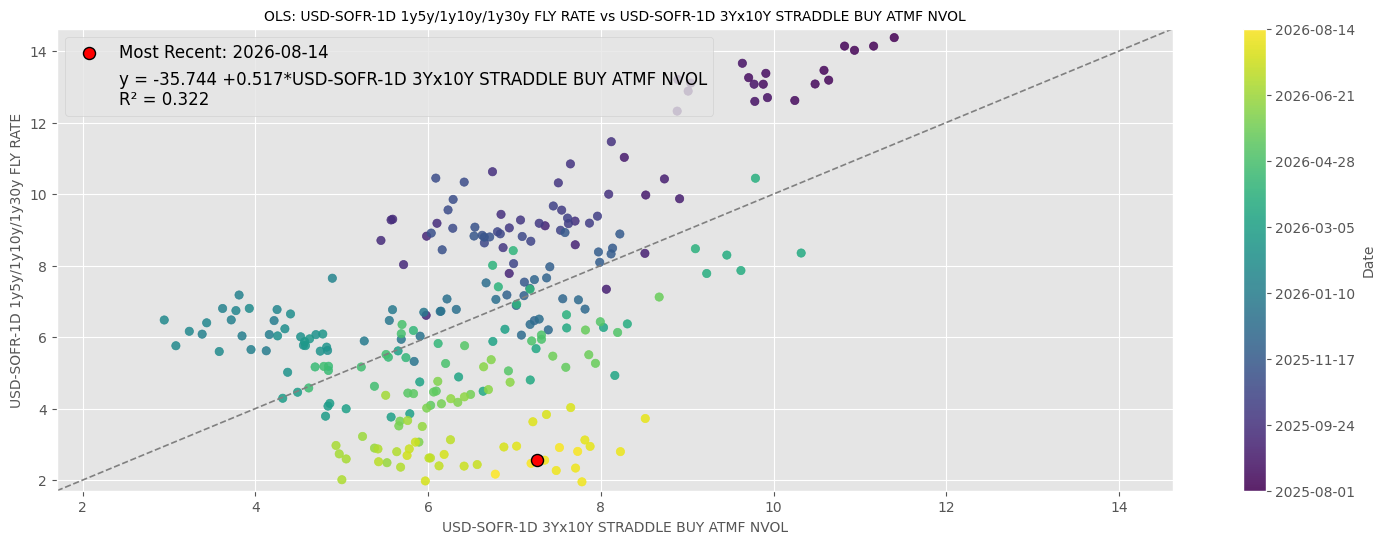

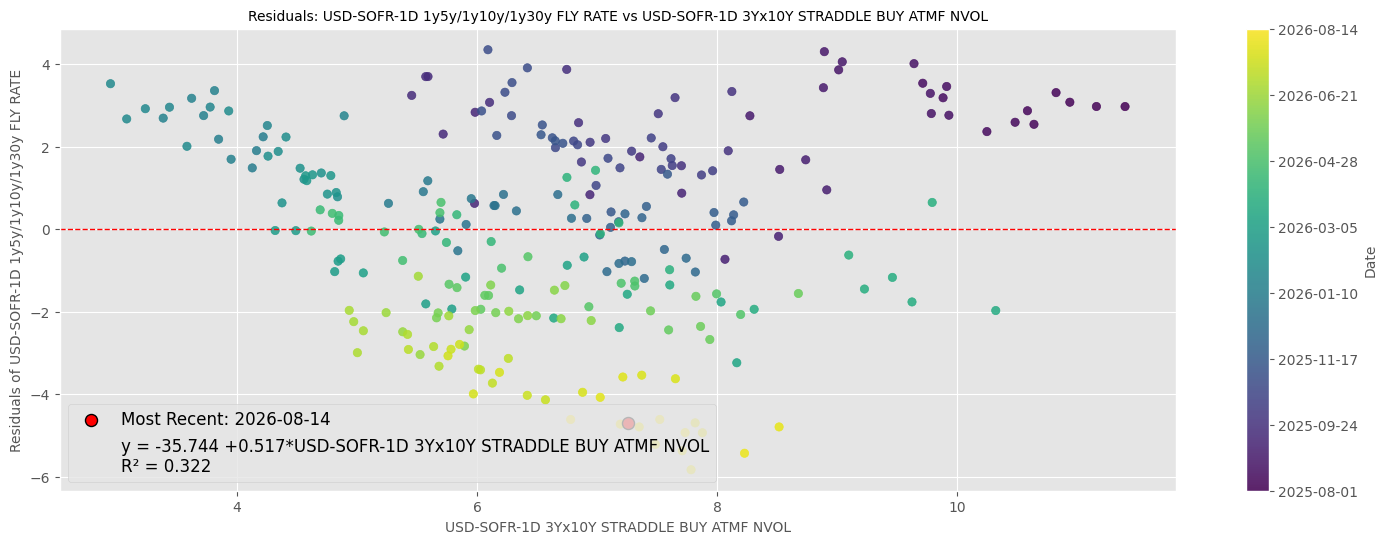

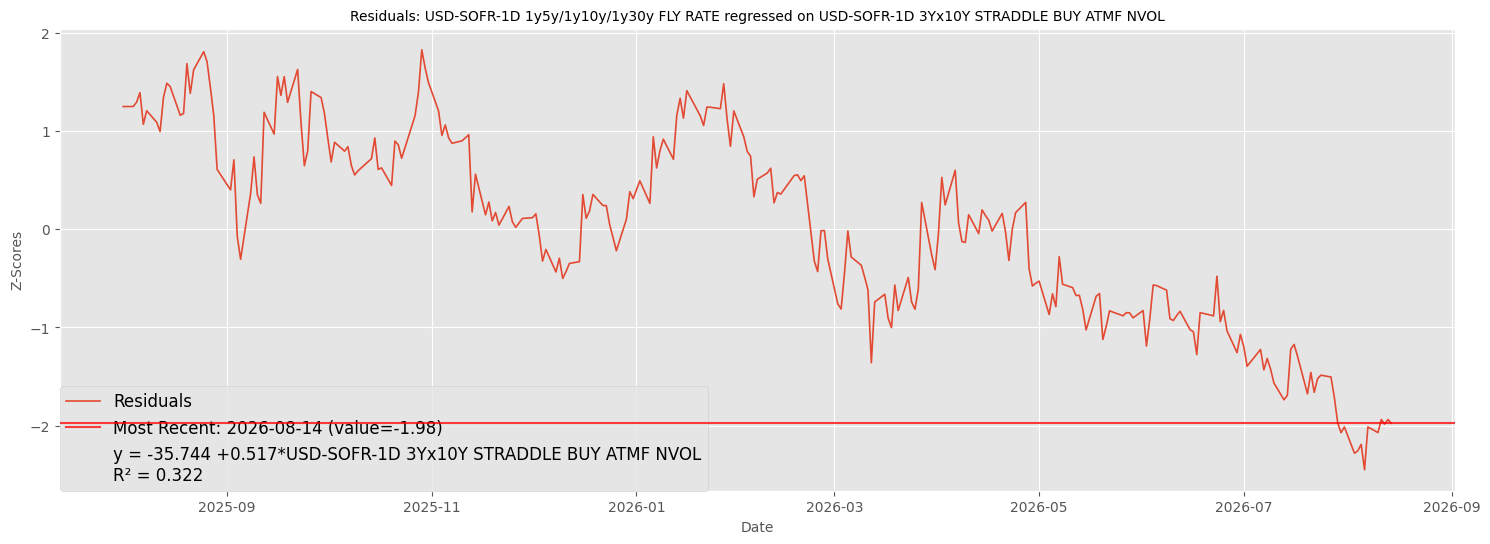

In [28]:
from RVUtils.regression import make_linear_regression_builder

add_indep_var, fit, plot_actual_vs_predicted, plot_residuals_vs_predicted, plot_residuals_timeseries, get_data = make_linear_regression_builder(
    df=df,
    y_col="USD-SOFR-1D 1y5y/1y10y/1y30y FLY RATE",
    date_color_bar=True,
	# on_diff=True
)
add_indep_var("USD-SOFR-1D 3Yx10Y STRADDLE BUY ATMF NVOL")
res = fit(model="OLS", verbose=True)
plot_actual_vs_predicted()
plot_residuals_vs_predicted()
# plot_residuals_timeseries(plot_zscores=True, plot_zero=True, stds=[1, 2], ou_bands=True)
plot_residuals_timeseries(plot_zscores=True, plot_zero=False, ou_bands=False)

PRICING FIXED-RATE BONDS.: 100%|██████████| 1/1 [00:00<00:00, 85.75it/s]


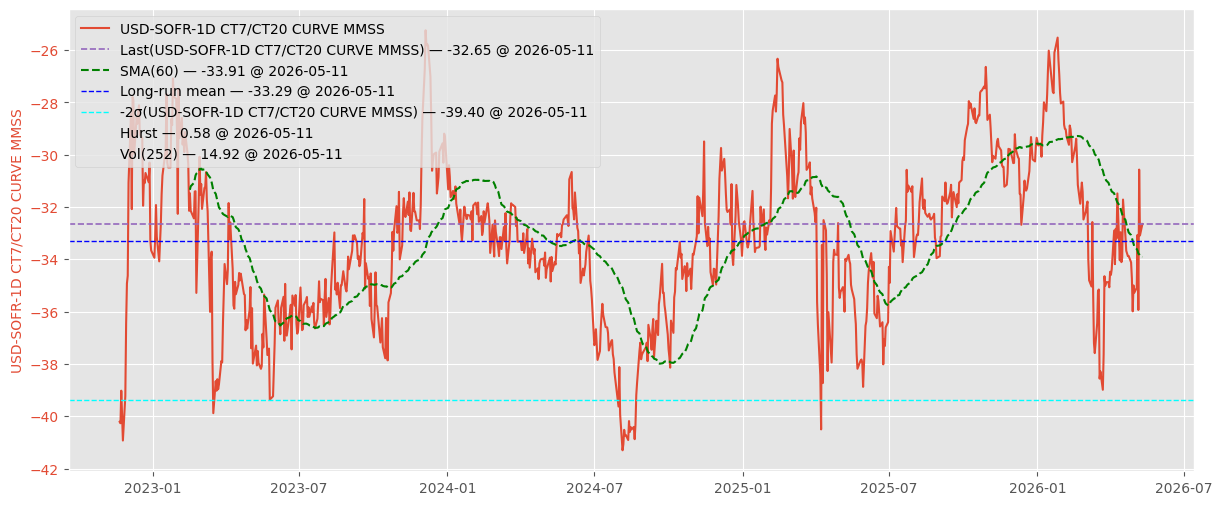

In [3]:
start = NYC_tz.localize(datetime.datetime(2022, 11, 20, 17, 00))
end = NYC_tz.localize(datetime.datetime(2026, 5, 11, 17, 00))
# end = "live" 

df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="CT7/CT20",
			# value=UnifiedValue.IRS_SPREADOVER,
			value=UnifiedValue.IRS_MMSS,
		),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			tenor="CT7/CT20",
			value=UnifiedValue.IRS_SPREADOVER,
		)
		# UnifiedQuery(
		# 	cusip="CT10",
		# 	value=UnifiedValue.FRB_YTM,
		# )
	],
    n_jobs=12,
	  routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
    },
)
df

# plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
plot, fig, ax, ax2, legend = make_secondary_axis_plot()

plot(
    df["USD-SOFR-1D CT7/CT20 CURVE MMSS"],
    which="left",
    indicators=[
        {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        {"kind": "sma", "window": 60, "style": {"linestyle": "--", "color": "green"}},
        {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "blue"}},
		{"kind": "hurst", "hide": True},
		{"kind": "vol", "returns": "normal", "window": 252, "hide": True},
		{
            "kind": "full_sigma",
            "n": 2,
            "hide_center": True,
            "hide_upper": True,
            "hide_lower": False,
            "style_upper": {"linestyle": "--", "color": "cyan"},
            "style_lower": {"linestyle": "--", "color": "cyan"},
        },
    ],
    # ou={"enable": True, "steps": 126, "add_metrics_to_legend": True}
)
# plot(df["USD-SOFR-1D 10y/30y CURVE RATE"], which="left")
# plot(df["USD-SOFR-1D 30y OUTRIGHT RATE"], which="right")
legend(show_date=True, loc="upper left")
plt.show()

In [15]:
import re
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

# seasonality_df = monthend_cumsum_seasonality(df[df.index > datetime.date(2025, 1, 1)].dropna(), window=20)
# seasonality_df = monthend_cumsum_seasonality(df[["USD-SOFR-1D 7Y/20Y CURVE SPREADOVER"]].dropna(), window=10)
seasonality_df = monthend_cumsum_seasonality(df[["USD-SOFR-1D IMM_3x1Y/IMM_3x3Y/IMM_3x5Y FLY RATE"]].dropna(), window=10)
display(seasonality_df)

fig = go.Figure()

me_col = f"avg"
# me_col = "avg-apr"
line_w = 1.25
min_op = 0.35
max_op = 0.85

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=seasonality_df.index,
        y=seasonality_df[me_col],
        mode="lines",
        name=f"{me_col}",
        line=dict(color="green", width=3),
    )
)
fig.add_hline(y=0, line_width=0.5, line_dash="dash", line_color="red")
if f"{me_col}+std1" in seasonality_df.columns and f"{me_col}-std1" in seasonality_df.columns:
    fig.add_trace(go.Scatter(x=seasonality_df.index, y=seasonality_df[f"{me_col}+std1"], mode="lines", line=dict(width=0), showlegend=False))
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[f"{me_col}-std1"],
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
            fillcolor="rgba(0, 255, 0, 0.10)",
            name="±1σ (template)",
        )
    )

n_last = 12
monthly_cols = [c for c in seasonality_df.columns if isinstance(c, str) and re.fullmatch(r"\d{4}-\d{2}", c)]
monthly_cols = sorted(monthly_cols)  # chronological
keep = monthly_cols[-n_last:] if n_last > 0 else []

# keep = ["2024-11", "2023-11", "2022-11", "2021-11", "2020-11"]

alphas = np.linspace(min_op, max_op, num=len(keep)) if keep else []
palette = px.colors.qualitative.Dark24 if hasattr(px.colors.qualitative, "Dark24") else px.colors.qualitative.Plotly
for i, col in enumerate(keep):
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[col],
            mode="lines",
            name=col,  # legend shows 'YYYY-MM'
            opacity=float(alphas[i]),
            line=dict(width=line_w, color=palette[i % len(palette)]),
        )
    )

fig.update_layout(
    xaxis_title=f"BDays from {me_col}",
    yaxis_title="Cum Delta",
    title=f"Seasonality: template={me_col}  |  last {len(keep)} months",
    showlegend=True,
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.01,
            y=1.10,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Hide months", method="update", args=[{"visible": [True, True, True] + [False] * len(keep)}]),
                dict(label="Show months", method="update", args=[{"visible": [True, True, True] + [True] * len(keep)}]),
            ],
        )
    ],
)
fig.update_xaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikemode="across", showgrid=True)
fig.update_yaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikethickness=0.5, showgrid=True)

fig.show(config={"modeBarButtonsToAdd": ["drawline", "drawopenpath", "drawclosedpath", "drawcircle", "drawrect", "eraseshape"]})

,avg,avg-std1,avg+std1,avg-std2,avg+std2,avg-jan,avg-jan-std1,avg-jan+std1,avg-jan-std2,avg-jan+std2,...,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
bdays_from_month_end,,,,,,,,,,,,,,,,,,,,,
-10,0.405,-6.219751,7.029751,-12.844503,13.654503,2.594943,-1.843463,7.03335,-6.28187,11.471756,...,1.984756,1.641974,-2.377892,-0.274623,7.714124,3.32413,0.04178,-2.223431,6.488389,0.0
-9,0.645311,-5.530539,6.821161,-11.706389,12.997011,2.377876,-2.526718,7.28247,-7.431312,12.187064,...,1.824103,1.399027,-0.928456,0.664543,6.982969,2.453968,0.429353,-1.109971,4.024792,0.921755
-8,1.084111,-4.159473,6.327696,-9.403058,11.571281,1.924483,-2.611501,6.460466,-7.147484,10.996449,...,1.569061,1.467029,-1.547816,0.383107,6.460771,-0.730596,0.629936,0.461481,3.342858,0.40307
-7,1.645576,-2.571522,5.862674,-6.78862,10.079772,1.942246,-1.783966,5.668457,-5.510177,9.394669,...,1.298021,0.355737,-0.135391,0.715998,6.896742,-2.4365,0.341878,1.231967,-0.455317,0.181924
-6,1.492358,-2.425613,5.410329,-6.343584,9.328299,2.354548,-0.702285,5.411382,-3.759118,8.468215,...,1.132873,0.544897,0.172712,2.092314,6.594749,-1.206885,0.309221,-0.305652,0.422671,-0.641226
-5,1.379406,-2.097497,4.85631,-5.574401,8.333213,1.684392,-1.120639,4.489423,-3.92567,7.294454,...,1.687973,0.741401,-0.112402,1.311788,4.77518,-2.597799,-0.041433,-0.536126,0.585413,<NA>
-4,1.241903,-1.748263,4.232069,-4.738429,7.222236,2.197142,-0.387625,4.781909,-2.972392,7.366675,...,1.751039,-0.204246,-0.458976,1.111568,1.323367,-2.315924,1.04173,-1.584709,1.220333,<NA>
-3,0.982242,-1.924321,3.888805,-4.830884,6.795367,2.369114,-0.232958,4.971187,-2.835031,7.573259,...,1.622453,-0.23446,-0.990262,0.954845,1.278144,-2.724557,0.816381,-1.478157,0.52011,<NA>
-2,0.772738,-1.77644,3.321916,-4.325618,5.871094,1.512885,-0.424682,3.450452,-2.362249,5.388018,...,0.455546,-1.154756,-0.024043,1.268257,2.217837,-0.704578,1.598085,-1.477307,0.76255,<NA>
